# Project 8: Customer Segmentation

## Objective

The objective of this project is to group customers into meaningful segments based on their characteristics.

Customer segmentation helps businesses understand different types of customers and develop targeted marketing strategies.

# Business Problem

Every customer behaves differently.

Some customers:
- Spend more money
- Stay with the company for a long time
- Purchase multiple services
- Frequently leave the company

Instead of treating every customer the same, businesses divide customers into similar groups.

This process is called **Customer Segmentation**.

Customer segmentation helps businesses:
- Improve marketing campaigns
- Increase customer satisfaction
- Reduce customer churn
- Increase revenue

# Machine Learning Workflow

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Feature Selection
5. Data Preprocessing
6. Feature Scaling
7. K-Means Clustering
8. Elbow Method
9. Customer Segmentation
10. Business Insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

# Load Dataset

The IBM Telco Customer Churn dataset is used for customer segmentation.

Unlike the previous project, the **Churn** column will not be used as the prediction target.

Instead, customers will be grouped based on similar characteristics.

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Cleaning

Before clustering, the dataset must be cleaned.

The following steps are performed:

- Replace blank values with NaN
- Convert TotalCharges to numeric
- Fill missing values using the median
- Remove customerID because it is only an identifier

In [5]:
df.replace(" ", np.nan, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df.drop("customerID", axis=1, inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Data Preprocessing

Machine learning algorithms require numerical input.

Categorical features are converted into numerical values before performing customer segmentation.

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = label_encoder.fit_transform(df[column])

In [8]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


# Feature Selection

Customer segmentation is an unsupervised learning problem.

There is no target variable.

Only customer attributes are used for clustering.

In [10]:
X = df.drop("Churn", axis=1)

In [11]:
print(X.shape)

(7043, 19)


# Feature Scaling

Feature scaling ensures that all variables contribute equally during clustering.

StandardScaler is used to standardize the dataset before applying K-Means.

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
print(X_scaled.shape)

(7043, 19)


# Elbow Method

The Elbow Method is used to determine the optimal number of clusters.

It calculates the inertia for different values of K and helps identify the point where adding more clusters provides diminishing returns.

In [14]:
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

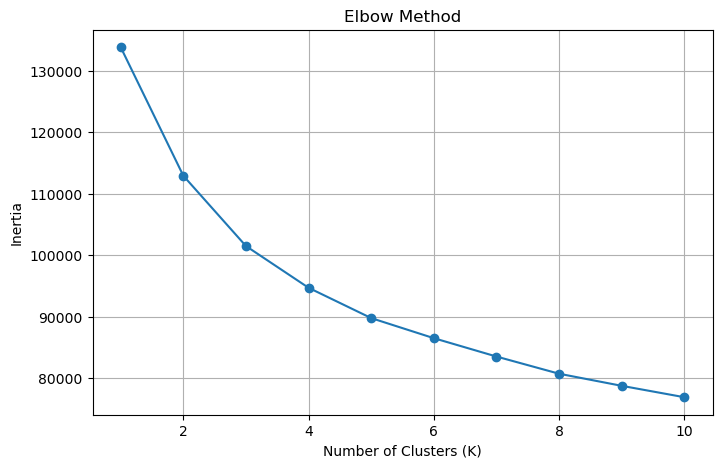

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

# Selecting the Number of Clusters

From the Elbow Method graph, select the value of K where the curve starts to flatten.

This value will be used for customer segmentation.

# K-Means Clustering

Based on the Elbow Method, the optimal number of clusters is selected as **4**.

The K-Means algorithm groups customers into four different segments based on their characteristics.

In [16]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [17]:
clusters = kmeans.fit_predict(X_scaled)

In [18]:
df["Cluster"] = clusters

In [19]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,0,1,2,29.85,29.85,0,0
1,1,0,0,0,34,1,0,0,2,0,...,0,0,0,1,0,3,56.95,1889.50,0,2
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,108.15,1,2
3,1,0,0,0,45,0,1,0,2,0,...,2,0,0,1,0,0,42.30,1840.75,0,0
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,151.65,1,2


In [20]:
df["Cluster"].value_counts().sort_index()

Cluster
0     662
1    1546
2    2744
3    2091
Name: count, dtype: int64

# Customer Segment Summary

The average values of each feature are calculated for every cluster.

This helps us understand the characteristics of different customer groups.

In [21]:
cluster_summary = df.groupby("Cluster").mean()

cluster_summary

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
Cluster,,,,,,,,,,,,,,,,,,,,
0,0.510574,0.151057,0.445619,0.296073,30.525680,0.000000,1.000000,0.000000,0.794562,0.806647,0.861027,0.812689,0.800604,0.839879,0.646526,0.563444,1.622356,41.333308,1404.720770,0.256798
1,0.509702,0.032988,0.487063,0.425614,30.460543,1.000000,0.441138,1.976067,1.009702,1.005821,0.999353,1.007115,0.991591,0.990298,1.077620,0.287840,1.838292,21.716235,681.446539,0.074386
2,0.500729,0.209913,0.313776,0.178207,15.980685,1.000000,0.790087,0.642857,0.401603,0.502915,0.444606,0.368076,0.633382,0.634111,0.102405,0.700802,1.766035,73.649435,1193.391117,0.459548
3,0.504543,0.198470,0.714012,0.366810,55.877092,0.990435,1.488283,0.635581,1.135820,1.394070,1.451459,1.199904,1.501196,1.512673,1.189861,0.683883,1.112386,92.341750,5171.417599,0.154472


In [23]:
cluster_summary[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "SeniorCitizen",
        "Partner"
    ]
].round(2)

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Partner
Cluster,,,,,
0,30.53,41.33,1404.72,0.15,0.45
1,30.46,21.72,681.45,0.03,0.49
2,15.98,73.65,1193.39,0.21,0.31
3,55.88,92.34,5171.42,0.20,0.71


# Business Insights

The K-Means algorithm grouped customers into four distinct segments.

## Cluster 0
Customers with moderate tenure who primarily use internet-based services.

## Cluster 1
Regular customers with moderate tenure and multiple telecom services.

## Cluster 2
Newer customers with fewer subscribed services. These customers may require engagement strategies to increase service adoption.

## Cluster 3
Long-term loyal customers with high service usage. These customers are valuable to the business and should be retained through loyalty programs.

# Conclusion

In this project, K-Means clustering was used to segment customers into four groups based on their characteristics.

The Elbow Method identified an appropriate number of clusters, and K-Means successfully grouped customers with similar behaviors.

Customer segmentation enables businesses to create targeted marketing strategies, improve customer satisfaction, and make better business decisions based on customer profiles.

In [24]:
cluster_summary.round(2).to_csv(
    "../outputs/customer_segment_summary.csv"
)